In [24]:
# Install dependencies
!pip install xarray zarr fsspec ipfsspec matplotlib

In [25]:
# Import Libraries
import xarray as xr
import zarr
import fsspec
import ipfsspec
import matplotlib.pyplot as plt
import os

In [26]:
os.environ["IPFS_GATEWAY"] = "https://ipfs.io"

# Accessing the data via the IPFS
data_url = "ipfs://bafybeihfqxfckruepjhrkafaz6xg5a4sepx6ahhv4zds4b3hnfiyj35c5i"

print(f"Attempting to access data from: {data_url}")

try:
    ds = xr.open_dataset(data_url, engine="zarr")
    print("Dataset successfully loaded!\n")
    
    # Display an overview of the data structure
    display(ds)
except Exception as e:
    print(f"Error: {e}")

Attempting to access data from: ipfs://bafybeihfqxfckruepjhrkafaz6xg5a4sepx6ahhv4zds4b3hnfiyj35c5i
Dataset successfully loaded!



<xarray.Dataset> Size: 116MB
Dimensions:                   (circle: 89, altitude: 1460, sonde: 1058)
Coordinates:
    circle_lat                (circle) float32 356B ...
    circle_lon                (circle) float32 356B ...
    circle_time               (circle) datetime64[ns] 712B ...
    sondes_per_circle         (circle) int64 712B ...
  * altitude                  (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
    launch_time               (sonde) datetime64[ns] 8kB ...
Dimensions without coordinates: circle, sonde
Data variables: (12/73)
    circle_altitude           (circle) float32 356B ...
    circle_id                 (circle) <U19 7kB ...
    circle_radius             (circle) float32 356B ...
    div                       (circle, altitude) float32 520kB ...
    div_sonde_relevance       (sonde, altitude) float32 6MB ...
    div_std_error             (circle, altitude) float32 520kB ...
    ...                        ...
    wspd_mean                 (circle, altitude) float32 520kB ...
    wvel                      (circle, altitude) float32 520kB ...
    wvel_sonde_relevance      (sonde, altitude) float32 6MB ...
    wvel_std_error            (circle, altitude) float32 520kB ...
    x                         (sonde, altitude) float32 6MB ...
    y                         (sonde, altitude) float32 6MB ...
Attributes:
    creator_email:  helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpimet...
    creator_name:   Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    featureType:    trajectoryProfile
    history:        Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 qual...
    keywords:       ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmospher...
    license:        CC-BY-4.0
    platform:       HALO
    project:        ORCESTRA, PERCUSION, MAESTRO
    references:     https://github.com/atmdrops/pydropsonde
    source:         dropsondes
    summary:        This dataset is the Level 4 BEACH dataset. It contains on...
    title:          BEACH dropsonde dataset (Level 4)

In [27]:
start_time = ds.circle_time.min().values
end_time = ds.circle_time.max().values

print(f"Data Start Date : {start_time}")
print(f"Data End Date   : {end_time}")

Data Start Date : 2024-08-11T14:45:42.500000000
Data End Date   : 2024-09-28T18:45:32.000000000


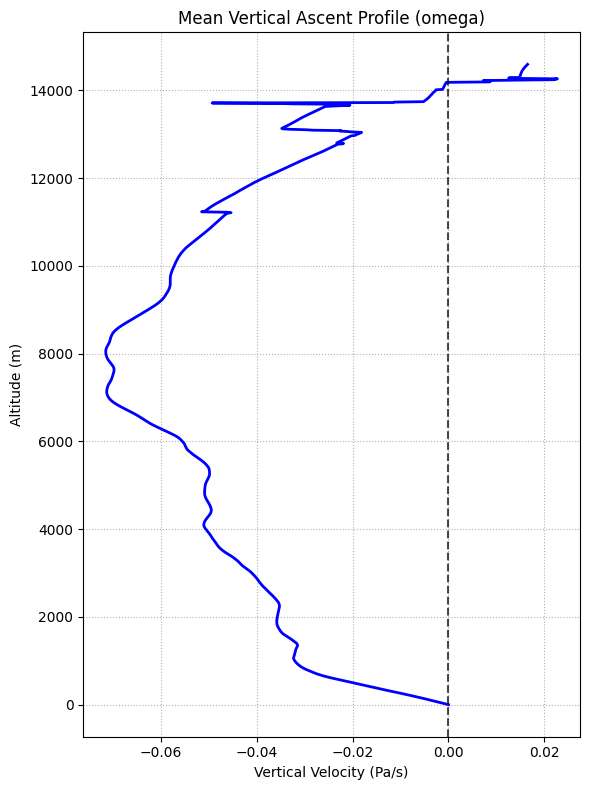

In [29]:
# Mean vertical velocity profile
var_w = 'wvel'
var_omega = 'omega'
omega_mean = ds[var_omega].mean(dim='circle', keep_attrs=True)

# Plot the vertical profile
plt.figure(figsize=(6, 8))

# Plotting against the 'altitude' dimension on the y-axis
omega_mean.plot(y='altitude', color='b', linewidth=2)

# Formatting the plot
plt.title("Mean Vertical Ascent Profile (omega)")
plt.xlabel("Vertical Velocity (Pa/s)")
plt.ylabel("Altitude (m)")
plt.axvline(x=0, color='k', linestyle='--', alpha=0.7) # Zero-reference line
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

Found 4 circles for 2024-08-13


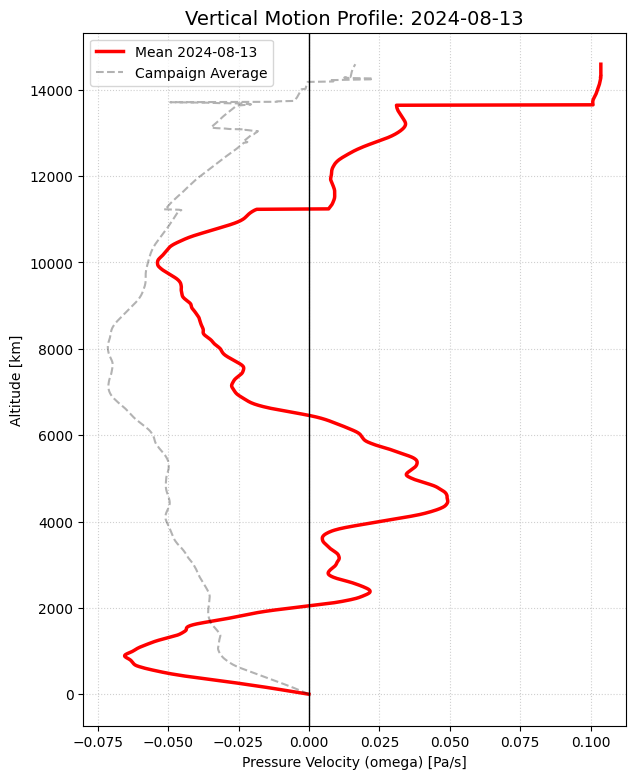

In [28]:
# 1. Choose a specific date within the campaign range (Aug 11 - Sept 28, 2024)
# Let's try August 15th as an example
selected_date = "2024-08-13"

# 2. Filter the dataset
# We use a slice to capture all circles flown on that calendar day
ds_subset = ds.sel(circle_time=slice(f"{selected_date}T00:00", f"{selected_date}T23:59"))

# 3. Validation and Plotting
if len(ds_subset.circle) > 0:
    print(f"Found {len(ds_subset.circle)} circles for {selected_date}")
    
    plt.figure(figsize=(7, 9))
    
    # Plot the mean omega for this specific day
    # We use 'omega' as it is a standard metric for large-scale vertical motion
    daily_omega = ds_subset['omega'].mean(dim='circle')
    daily_omega.plot(y='altitude', color='red', linewidth=2.5, label=f'Mean {selected_date}')
    
    # Reference: Campaign Average (optional but helpful for context)
    ds['omega'].mean(dim='circle').plot(y='altitude', color='black', 
                                        linestyle='--', alpha=0.3, label='Campaign Average')

    plt.title(f"Vertical Motion Profile: {selected_date}", fontsize=14)
    plt.axvline(x=0, color='black', linewidth=1)
    plt.xlabel("Pressure Velocity (omega) [Pa/s]")
    plt.ylabel("Altitude [km]")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
else:
    print(f"No data available for {selected_date}. Please select another date.")